# Detected endpoints: ASOCA vs MACS-18

Overlapping **histogram bins** and **filled KDE curves** (blue = ASOCA, orange = MACS-18) for detected endpoints per patient; x-axis starts at **0**.

**Data:** hardcoded per-patient counts from the experimental summary (`TFG Results v2`).
- **MACS-18:** detected endpoints per patient (section 1.2).
- **ASOCA:** total detected endpoints per patient (denominator from section 1.2 precision table).

Exports: `exports/fig_endpoints_distribution_asoca_vs_macs.png` (+ copy to thesis `figures/`).

## 1. Setup

**Kernel → Restart** before running this notebook if matplotlib failed in an earlier cell (avoids a half-loaded package).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import display

# Drop broken partial imports from a previous failed run in this kernel.
for _name in list(sys.modules):
    if _name == "matplotlib" or _name.startswith("matplotlib."):
        del sys.modules[_name]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR
while not (PROJECT_ROOT / "src" / "blocks" / "_01_extraction.py").is_file():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise RuntimeError(
            "Could not locate repo root. Run Jupyter from the repo or from "
            "notebooks/results visualizations."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent

EXPORT_DIR = NOTEBOOK_DIR / "exports"
THESIS_FIG_DIR = PROJECT_ROOT / "thesis" / "TFG_Latex2526" / "figures"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
THESIS_FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

COLOR_ASOCA = "#3182bd"   # blue
COLOR_MACS = "#e6550d"    # orange
HIST_ALPHA = 0.42
KDE_LINEWIDTH = 2.2

print(f"Exports : {EXPORT_DIR}")

Exports : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports


## 2. Hardcoded endpoint counts per patient

In [7]:
# MACS-18 — detected endpoints per patient (TFG Results v2, section 1.2)
ENDPOINTS_MACS_18: dict[str, int] = {
    "Normal_1": 28,
    "Diseased_1": 16,
    "Normal_2": 25,
    "Diseased_2": 24,
    "Normal_3": 42,
    "Diseased_3": 27,
    "Normal_4": 22,
    "Diseased_4": 32,
    "Normal_5": 24,
    "Diseased_5": 33,
    "Normal_6": 22,
    "Diseased_6": 19,
    "Normal_7": 27,
    "Diseased_7": 28,
    "Normal_8": 28,
    "Diseased_8": 21,
    "Normal_9": 35,
    "Diseased_9": 42,
    "Normal_10": 31,
    "Diseased_10": 15,
    "Normal_11": 57,
    "Diseased_11": 20,
    "Normal_12": 17,
    "Diseased_12": 12,
    "Normal_13": 64,
    "Diseased_13": 21,
    "Normal_14": 33,
    "Diseased_14": 23,
    "Normal_15": 30,
    "Diseased_15": 21,
    "Normal_16": 26,
    "Diseased_16": 31,
    "Normal_17": 23,
    "Diseased_17": 23,
    "Normal_18": 25,
    "Diseased_18": 32,
    "Normal_19": 24,
    "Diseased_19": 27,
    "Normal_20": 32,
    "Diseased_20": 26,
}

# ASOCA — total detected endpoints (denominator from precision table, section 1.2)
ENDPOINTS_ASOCA: dict[str, int] = {
    "Normal_1": 16,
    "Diseased_1": 10,
    "Normal_2": 12,
    "Diseased_2": 11,
    "Normal_3": 20,
    "Diseased_3": 16,
    "Normal_4": 13,
    "Diseased_4": 15,
    "Normal_5": 20,
    "Diseased_5": 21,
    "Normal_6": 12,
    "Diseased_6": 20,
    "Normal_7": 15,
    "Diseased_7": 15,
    "Normal_8": 19,
    "Diseased_8": 18,
    "Normal_9": 16,
    "Diseased_9": 15,
    "Normal_10": 17,
    "Diseased_10": 11,
    "Normal_11": 23,
    "Diseased_11": 16,
    "Normal_12": 15,
    "Diseased_12": 15,
    "Normal_13": 32,
    "Diseased_13": 22,
    "Normal_14": 30,
    "Diseased_14": 19,
    "Normal_15": 12,
    "Diseased_15": 13,
    "Normal_16": 13,
    "Diseased_16": 17,
    "Normal_17": 16,
    "Diseased_17": 19,
    "Normal_18": 23,
    "Diseased_18": 21,
    "Normal_19": 19,
    "Diseased_19": 12,
    "Normal_20": 21,
    "Diseased_20": 14,
}


def _dict_to_dataframe(counts: dict[str, int], cohort: str) -> pd.DataFrame:
    rows = []
    for patient_id, n in counts.items():
        subtype = "Normal" if patient_id.startswith("Normal") else "Diseased"
        rows.append(
            {
                "cohort": cohort,
                "patient_id": patient_id,
                "subtype": subtype,
                "n_endpoints_detected": n,
            }
        )
    return pd.DataFrame(rows)


df_endpoints = pd.concat(
    [
        _dict_to_dataframe(ENDPOINTS_ASOCA, "ASOCA"),
        _dict_to_dataframe(ENDPOINTS_MACS_18, "MACS-18"),
    ],
    ignore_index=True,
)

assert len(df_endpoints) == 80, f"Expected 80 rows, got {len(df_endpoints)}"
print(df_endpoints.groupby("cohort")["n_endpoints_detected"].agg(["count", "mean", "min", "max"]))
df_endpoints.head(8)

         count  mean  min  max
cohort                        
ASOCA       40  17.1   10   32
MACS-18     40  27.7   12   64


,cohort,patient_id,subtype,n_endpoints_detected
0,ASOCA,Normal_1,Normal,16
1,ASOCA,Diseased_1,Diseased,10
2,ASOCA,Normal_2,Normal,12
3,ASOCA,Diseased_2,Diseased,11
4,ASOCA,Normal_3,Normal,20
5,ASOCA,Diseased_3,Diseased,16
6,ASOCA,Normal_4,Normal,13
7,ASOCA,Diseased_4,Diseased,15


## 3. Summary comparison table (ASOCA vs MACS-18)

Per-cohort statistics for detected endpoints (All / Normal / Diseased). Exported to `exports/endpoints_summary_comparison.csv`.

In [10]:
def build_endpoint_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    """One row per cohort × subgroup with descriptive endpoint statistics."""
    rows: list[dict] = []
    for cohort in ("ASOCA", "MACS-18"):
        cohort_df = df.loc[df["cohort"] == cohort]
        for subgroup, mask in (
            ("All", slice(None)),
            ("Normal", cohort_df["subtype"] == "Normal"),
            ("Diseased", cohort_df["subtype"] == "Diseased"),
        ):
            vals = cohort_df.loc[mask, "n_endpoints_detected"].astype(float)
            rows.append(
                {
                    "Cohort": cohort,
                    "Subgroup": subgroup,
                    "n": int(vals.count()),
                    "Mean": round(vals.mean(), 2),
                    "Std": round(vals.std(ddof=1), 2) if len(vals) > 1 else 0.0,
                    "Min": int(vals.min()),
                    "Max": int(vals.max()),
                    "Median": round(float(vals.median()), 2),
                    "Total": int(vals.sum()),
                }
            )
    return pd.DataFrame(rows)


summary_table = build_endpoint_summary_table(df_endpoints)
display(summary_table)

SUMMARY_CSV = EXPORT_DIR / "endpoints_summary_comparison.csv"
summary_table.to_csv(SUMMARY_CSV, index=False)
print(f"Saved: {SUMMARY_CSV}")

,Cohort,Subgroup,n,Mean,Std,Min,Max,Median,Total
0,ASOCA,All,40,17.10,4.78,10,32,16.0,684
1,ASOCA,Normal,20,18.20,5.61,12,32,16.5,364
2,ASOCA,Diseased,20,16.00,3.58,10,22,15.5,320
3,MACS-18,All,40,27.70,10.00,12,64,26.0,1108
4,MACS-18,Normal,20,30.75,11.60,17,64,27.5,615
5,MACS-18,Diseased,20,24.65,7.15,12,42,23.5,493


Saved: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports\endpoints_summary_comparison.csv


## 4. Histogram bins + filled KDE curves (x-axis from 0)

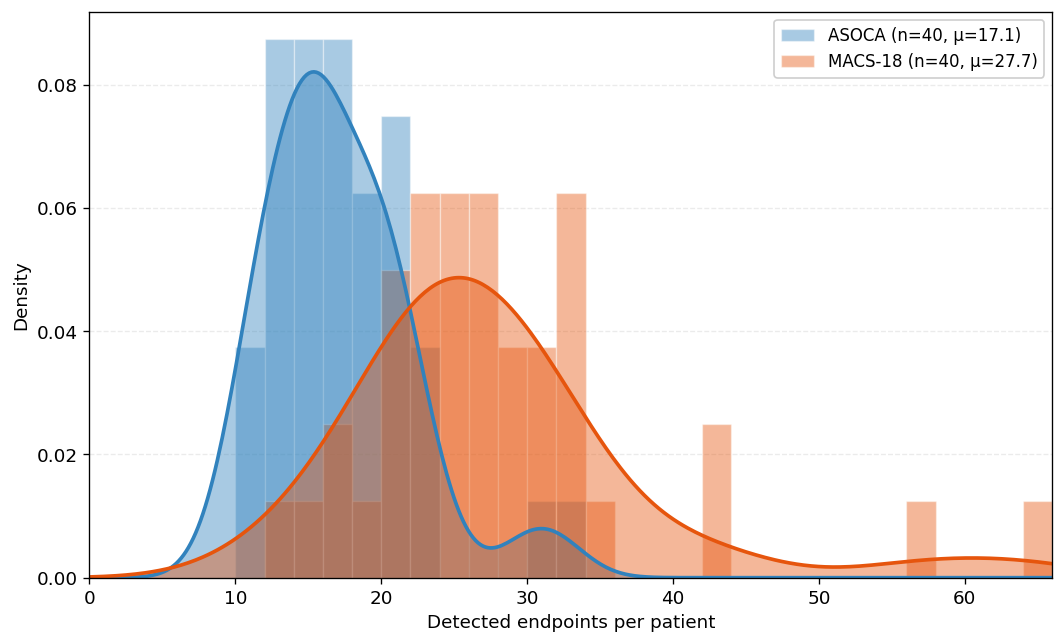

In [5]:
def _plot_kde_fill(
    ax: plt.Axes,
    values: np.ndarray,
    *,
    color: str,
    x_grid: np.ndarray,
) -> None:
    """KDE curve with light filled area under the density."""
    if len(np.unique(values)) <= 1:
        return
    kde = gaussian_kde(values)
    y = kde(x_grid)
    ax.fill_between(
        x_grid,
        y,
        0.0,
        color=color,
        alpha=HIST_ALPHA,
        linewidth=0,
    )
    ax.plot(x_grid, y, color=color, linewidth=KDE_LINEWIDTH)


def plot_endpoints_distribution(
    df: pd.DataFrame,
    *,
    figsize: tuple[float, float] = (9.0, 5.5),
    bin_width: int = 2,
) -> tuple[plt.Figure, plt.Axes]:
    """Overlapping histogram bins + filled KDE curves (x-axis from 0)."""
    asoca = df.loc[df["cohort"] == "ASOCA", "n_endpoints_detected"].to_numpy(dtype=float)
    macs = df.loc[df["cohort"] == "MACS-18", "n_endpoints_detected"].to_numpy(dtype=float)

    all_vals = np.concatenate([asoca, macs])
    x_min = 0.0
    x_max = float(np.ceil(all_vals.max()) + 2)
    bins = np.arange(x_min, x_max + bin_width, bin_width)
    x_grid = np.linspace(x_min, x_max, 400)

    fig, ax = plt.subplots(figsize=figsize)

    ax.hist(
        asoca,
        bins=bins,
        density=True,
        alpha=HIST_ALPHA,
        color=COLOR_ASOCA,
        edgecolor="white",
        linewidth=0.8,
        label=f"ASOCA (n={len(asoca)}, μ={asoca.mean():.1f})",
    )
    ax.hist(
        macs,
        bins=bins,
        density=True,
        alpha=HIST_ALPHA,
        color=COLOR_MACS,
        edgecolor="white",
        linewidth=0.8,
        label=f"MACS-18 (n={len(macs)}, μ={macs.mean():.1f})",
    )

    _plot_kde_fill(ax, asoca, color=COLOR_ASOCA, x_grid=x_grid)
    _plot_kde_fill(ax, macs, color=COLOR_MACS, x_grid=x_grid)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Detected endpoints per patient")
    ax.set_ylabel("Density")
    ax.legend(loc="upper right", framealpha=0.95)
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_endpoints_distribution(df_endpoints)
plt.show()

## 5. Export figure

In [6]:
FIG_STEM = "fig_endpoints_distribution_asoca_vs_macs"
out_nb = EXPORT_DIR / f"{FIG_STEM}.png"
out_tex = THESIS_FIG_DIR / f"{FIG_STEM}.png"

fig, _ = plot_endpoints_distribution(df_endpoints)
fig.savefig(out_nb, bbox_inches="tight")
fig.savefig(out_tex, bbox_inches="tight")
plt.close(fig)

print(f"Saved: {out_nb}")
print(f"Saved: {out_tex}")

Saved: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports\fig_endpoints_distribution_asoca_vs_macs.png
Saved: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\thesis\TFG_Latex2526\figures\fig_endpoints_distribution_asoca_vs_macs.png
